# Task : Conditional Posterior Derivation

In this section, we derive the full conditional posterior distributions for the parameters of the finite mixture model. 

##  Conditional Posterior of $\mu_k$
For each component $k \in \{1, 2, 3\}$, we assume an independent conjugate Normal prior: $\mu_k \sim \mathcal{N}(\underline{m}_k, \underline{s}_k^2)$.
We know that the conditional posterior is proportional to the product of this prior and the likelihood of observations currently assigned to component, thus
$k$:$$p(\mu_k | z, y, \sigma_k^2) \propto p(\mu_k) \times p(y, z | \mu, \sigma^2, \phi)$$
Substituting the Normal densities and dropping constants independent of $\mu_k$:$$p(\mu_k | z, y, \sigma_k^2) \propto \exp \left( -\frac{1}{2\underline{s}_k^2} (\mu_k - \underline{m}_k)^2 \right) \times \prod_{t=1}^T \left[ \exp \left( -\frac{1}{2\sigma_k^2} (y_t - \mu_k)^2 \right) \right]^{\mathbb{I}(z_t = k)}$$
By taking the natural logarithm and expanding the quadratic terms, the log-posterior kernel is expressed as:$$\ln p(\mu_k | z, y, \sigma_k^2) = -\frac{1}{2} \left[ \frac{\mu_k^2 - 2\mu_k \underline{m}_k + \underline{m}_k^2}{\underline{s}_k^2} + \frac{\sum_{t=1}^T (y_t^2 - 2y_t \mu_k + \mu_k^2)\mathbb{I}(z_t = k)}{\sigma_k^2} \right] + C$$Isolating the terms involving $\mu_k$ while absorbing constant terms (independent of $\mu_k$) into $C'$ yields:
$$\ln p(\mu_k | z, y, \sigma_k^2) = -\frac{1}{2} \left[ \mu_k^2 \underbrace{\left( \frac{1}{\underline{s}_k^2} + \frac{\sum_{t=1}^T \mathbb{I}(z_t = k)}{\sigma_k^2} \right)}_{A} - 2\mu_k \underbrace{\left( \frac{\underline{m}_k}{\underline{s}_k^2} + \frac{\sum_{t=1}^T y_t \mathbb{I}(z_t = k)}{\sigma_k^2} \right)}_{B} \right] + C'$$
Substituting the sufficient statistics $n_k = \sum_{t=1}^T \mathbb{I}(z_t = k)$ and $s_k = \sum_{t=1}^T y_t \mathbb{I}(z_t = k)$ as defined, the coefficients $A$ and $B$ simplify to:
$$A = \frac{1}{\underline{s}_k^2} + \frac{n_k}{\sigma_k^2}, \quad B = \frac{\underline{m}_k}{\underline{s}_k^2} + \frac{s_k}{\sigma_k^2}$$
The log-posterior kernel is thus $\ln p(\mu_k | z, y, \sigma_k^2) = -\frac{1}{2} [ A\mu_k^2 - 2B\mu_k ] + C'$.To identify the parameters of the distribution, we complete the square for $\mu_k$:$$\begin{aligned}\ln p(\mu_k | z, y, \sigma_k^2) &= -\frac{1}{2} A \left[ \mu_k^2 - 2\mu_k \frac{B}{A} + \left( \frac{B}{A} \right)^2 \right] + C'' \\
\ln p(\mu_k | z, y, \sigma_k^2) &= -\frac{1}{2} A \left( \mu_k - \frac{B}{A} \right)^2 + C''
\end{aligned}$$Comparing this to the standard form of a Normal log-density $-\frac{1}{2\bar{s}_k^2}(\mu_k - \bar{m}_k)^2$, we directly identify the conditional posterior is:$$\mu_k | z, y, \sigma_k^2 \sim \mathcal{N}\left( \bar{m}_k, \bar{s}_k^2 \right)$$where Posterior Variance:$$\bar{s}_k^2 = A^{-1} = \left( \frac{n_k}{\sigma_k^2} + \frac{1}{\underline{s}_k^2}\right)^{-1}$$
and Posterior Mean:$$\overline{m}_k := \overline{s}_k^2 \left( \frac{1}{\sigma_k^2} \sum_{t=1}^T y_t \mathbb{I}(z_t = k) + \frac{\underline{m}_k}{\underline{s}_k^2} \right)$$

## Conditional Posterior of $\sigma_k^2$
For each component $k \in \{1, \dots, K\}$, we assume an independent conjugate Inverse-Gamma prior for the variance: $\sigma_k^2 \sim \mathcal{IG}(\underline{a}_k, \underline{b}_k)$. 

The prior density is proportional to:$$p(\sigma_k^2) \propto (\sigma_k^2)^{-(\underline{a}_k + 1)} \exp\left(-\frac{\underline{b}_k}{\sigma_k^2}\right)$$
The conditional posterior of $\sigma_k^2$ is proportional to the product of this prior and the portion of the complete-data likelihood involving $\sigma_k^2$:$$p(\sigma_k^2 \mid z, y, \mu_k) \propto p(\sigma_k^2) \times \prod_{t=1}^T \left[ p(y_t \mid z_t=k, \mu_k, \sigma_k^2) \right]^{\mathbb{I}(z_t=k)}$$
Given the Normal likelihood $y_t \mid (z_t=k, \mu_k, \sigma_k^2) \sim \mathcal{N}(\mu_k, \sigma_k^2)$, we have for the observations assigned to cluster $k$:$$p(y_t \mid z_t=k, \mu_k, \sigma_k^2) \propto (\sigma_k^2)^{-1/2} \exp\left(-\frac{(y_t - \mu_k)^2}{2\sigma_k^2}\right)$$
Substituting the Inverse-Gamma prior and this likelihood, and dropping multiplicative constants independent of $\sigma_k^2$, yields:$$p(\sigma_k^2 \mid z, y, \mu_k) \propto (\sigma_k^2)^{-(\underline{a}_k + 1)} \exp\left(-\frac{\underline{b}_k}{\sigma_k^2}\right) \prod_{t=1}^T \left[ (\sigma_k^2)^{-1/2} \exp\left(-\frac{(y_t - \mu_k)^2}{2\sigma_k^2}\right) \right]^{\mathbb{I}(z_t=k)}$$
By collecting powers of $\sigma_k^2$ and terms within the exponential function, we obtain:$$\begin{aligned}
p(\sigma_k^2 \mid z, y, \mu_k) &\propto (\sigma_k^2)^{-(\underline{a}_k + 1)} \prod_{t=1}^T (\sigma_k^2)^{-\frac{1}{2}\mathbb{I}(z_t=k)} \exp\left(-\frac{1}{\sigma_k^2} \left[ \underline{b}_k + \frac{1}{2} \sum_{t=1}^T (y_t - \mu_k)^2 \mathbb{I}(z_t=k) \right]\right) \\
&\propto (\sigma_k^2)^{-\left(\underline{a}_k + 1 + \frac{1}{2} \sum_{t=1}^T \mathbb{I}(z_t=k)\right)} \exp\left(-\frac{1}{\sigma_k^2} \left[ \underline{b}_k + \frac{1}{2} \sum_{t=1}^T (y_t - \mu_k)^2 \mathbb{I}(z_t=k) \right]\right)
\end{aligned}$$Using the sufficient statistic $n_k = \sum_{t=1}^T \mathbb{I}(z_t = k)$, the expression simplifies to:$$p(\sigma_k^2 \mid z, y, \mu_k) \propto (\sigma_k^2)^{-\left(\underline{a}_k + \frac{n_k}{2}\right) - 1} \exp\left(-\frac{\underline{b}_k + \frac{1}{2} \sum_{t=1}^T (y_t - \mu_k)^2 \mathbb{I}(z_t = k)}{\sigma_k^2}\right)$$
This is the kernel of an Inverse-Gamma distribution with updated shape and scale parameters.
Thus, the conditional posterior is:$$\sigma_k^2 \mid z, y, \mu_k \sim \mathcal{IG}(\bar{a}_k, \bar{b}_k)$$where Posterior Shape:$$\bar{a}_k = \underline{a}_k + \frac{n_k}{2}$$and Posterior Scale:$$\bar{b}_k = \underline{b}_k + \frac{1}{2} \sum_{t=1}^T (y_t - \mu_k)^2 \mathbb{I}(z_t = k)$$

## Conditional Posterior of $z_t$
First, find prior and posterior.
Because probability that any observation belongs to a given cluster k is denoted as $\phi_k = P(z_t = k) $. Thus:$$Prior: P(z_t = k) = \phi_k$$

And within each market state k (conditional on $z_t$ = k) returns follow a normal distribution with mean $\mu_k$ and variance $\sigma^2$. So:
$$Likelihood： p(y_t \mid z_t = k, \mu_k, \sigma_k^2) = \mathcal{N}(y_t \mid \mu_k, \sigma_k^2) $$

Next, Construct unnormalized kernel by using equation: prior * likelihood.
$$Kernel: p(z_t = k \mid y_t, \mu_t, \sigma_t^2) \propto \phi_k \cdot \mathcal{N}(y_t \mid \mu_k, \sigma_k^2)$$

Final step: Normalization by construct normalization constant.
Normalization constant ：
$$\text{Constant} = \sum_{l=1}^{K} \left[ \phi_l \cdot \mathcal{N}(y_t \mid \mu_l, \sigma_l^2) \right]$$
divdent kernel by normalization constant:  $\pi_{kt}$ ：
$$P(z_t = k \mid y_t, \mu, \sigma^2, \phi) = \frac{\phi_k \cdot \mathcal{N}(y_t \mid \mu_k, \sigma_k^2)}{\sum_{l=1}^{K} \phi_l \cdot \mathcal{N}(y_t \mid \mu_l, \sigma_l^2)}$$

Which means $z_t$ obey $(\pi_{1t}, \dots, \pi_{Kt})$  Categorical distribution.

## Conditional Posterior of $\phi$
First, according the Bayes rule，the posterior distribution of $\phi$ is：$$p(\phi \mid z) \propto p(z \mid \phi) \cdot p(\phi)$$

Then, the prior distribution of $\phi$ given by document: $$p(\phi) \sim \text{Dirichlet}(\underline{p}_1, \dots, \underline{p}_K) \propto \prod_{k=1}^{K} \phi_k^{\underline{p}_k - 1}$$

Next, the likelihood part is a combination.
We can use indicator function to define $$p(z_t | \phi) = \prod_{k=1}^K \phi_k^{\mathbb{I}(z_t=k)}$$
We have $T$ observations, Thus $$p(z|\phi) = \prod_{t=1}^T p(z_t|\phi)$$
The likelihood function can be written as：$$p(z \mid \phi) \propto \prod_{k=1}^{K} \phi_k^{n_k}$$

Last step: Posterior Derivation：$$p(\phi \mid z) \propto \left( \prod_{k=1}^{K} \phi_k^{\underline{p}_k - 1} \right) \times \left( \prod_{k=1}^{K} \phi_k^{n_k} \right)$$
Thus：$$p(\phi \mid z) \propto \prod_{k=1}^{K} \phi_k^{(\underline{p}_k + n_k) - 1}$$
Conclusion：The posterior of $\phi$ ：$$\phi \mid z \sim \text{Dirichlet}(\overline{p}_1, \dots, \overline{p}_K)$$ where $\overline{p}_k = \underline{p}_k + n_k$.

# Task : Gibbs Sampling Algorithm Implementation

We implemented a Gibbs sampling algorithm from scratch to simulate the posterior distribution of the finite mixture model parameters. The algorithm iteratively samples from the full conditional distributions derived in Task 1.

## Algorithm Overview

The Gibbs sampler follows these steps for each iteration $i = 1, \dots, N$:

1.  **Initialize Parameters:**
    * Set initial values for $\underline{\mu}$, $\underline{\sigma^2}$, and $\underline{\phi}$.
    *   Randomly assign initial cluster indicators $\underline{z}$.

2.  **Step 1: Sample Latent Variables ($z$)**
    *   For each observation $t$, calculate the probability of belonging to each cluster $k$ based on the current parameters:
        $$ \pi_{kt} \propto \phi_k^{(i-1)} \cdot \mathcal{N}(y_t \mid \mu_k^{(i-1)}, {\sigma^2_k}^{(i-1)}) $$
    *   Sample $z_t^{(i)}$ from a Categorical distribution with probabilities $(\pi_{1t}, \dots, \pi_{Kt})$.

3.  **Step 2: Sample Means ($\mu$)**
    *   Calculate sufficient statistics (sample count $n_k$ and sum of observations) for each cluster based on $z^{(i)}$.
    *   Sample $\mu_k^{(i)}$ from the conditional Normal posterior $\mathcal{N}(\overline{m}_k, \overline{s}_k^2)$.

4.  **Step 3: Sample Variances ($\sigma^2$)**
    *   Calculate the Sum of Squared Errors (SSE) for each cluster.
    *   Sample ${\sigma^2_k}^{(i)}$ from the conditional Inverse-Gamma posterior $\mathcal{IG}(\overline{a}_k, \overline{b}_k)$.

5.  **Step 4: Sample Mixing Probabilities ($\phi$)**
    *   Update Dirichlet parameters $\overline{p_k} = \underline{p_k} + n_k$.
    *   Sample $\phi^{(i)}$ from the Dirichlet distribution $\text{Dir}(\overline{p_1}, \dots, \overline{p_K})$.

6.  **Step 5: Random Permutation (Bonus)**
    *   To mitigate label switching and ensure robust exploration, we randomly permute the labels of components at the end of each iteration.
    *   (Details already discussed in the phase 3 and 4section).

This process is repeated for a total of 20,000 iterations, with the first 5,000 discarded as burn-in to ensure convergence to the stationary distribution.

# Task : Application to S&P 500 Data

We applied the Gibbs sampling algorithm to the daily returns of the Standard & Poor's 500 (S&P 500) index.

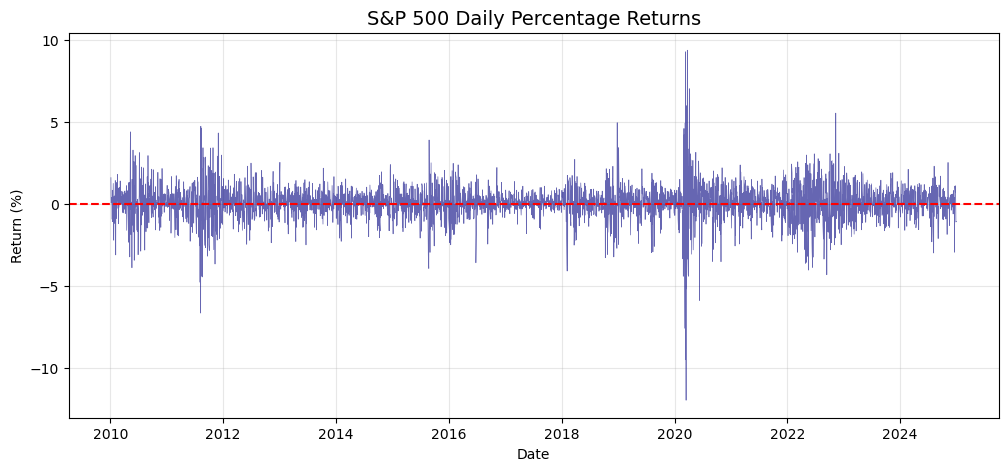

## Data Processing
*   **Dataset:** Daily adjusted closing prices of the S&P 500 index from December 31, 2009, to 2024.
*   **Return Calculation:** The daily percentage returns $y_t$ were calculated as:
    $$ y_t = 100 \times \left( \frac{P_t}{P_{t-1}} - 1 \right) $$
    where $P_t$ is the adjusted price on day $t$.
*   **Observation:** The dataset contains 3,773 observations. The time series plot of returns reveals periods of high volatility clustering, particularly around 2020, suggesting that a single Normal distribution is insufficient to model the data.

## Model Settings
*   **Number of Components:** We set $K=3$ as document to capture three distinct market regimes: Recession, Stable, and Growth.
*   **Hyperparameters:** Weakly informative priors were chosen to let the data drive the inference:
    *   $\mu_k \sim \mathcal{N}(0, 100)$
    *   $\sigma_k^2 \sim \mathcal{IG}(2, 1)$ (Finite variance prior)
    *   $\phi \sim \text{Dirichlet}(1, 1, 1)$ (Uniform prior)
*   **Simulation:** The MCMC chain was run for 20,000 iterations with a burn-in period of 5,000. To reduce autocorrelation, we applied a thinning factor of 5, resulting in 3,000 posterior samples for analysis. We also use seed which is 78 for replication.

## Mixed Lable problem (About bonus)
We create a variable named $trace\_mu\_raw$ here for comparison in section 4 and try to complete the bonus part.

# Task : Posterior Summaries and Trace Plots

This section presents posterior summaries for all model parameters and evaluates chain convergence through trace plots.

## Posterior Summary Statistics

The table below shows the posterior mean and 95% credible intervals for each parameter, sorted by mean return (lowest to highest).


| Parameter                   | Cluster 0 (Recession)    | Cluster 2 (Stable)    | Cluster 1 (Growth)    |
| --------------------------- | ------------------------ | --------------------- | --------------------- |
| $\mu$ (Mean Return %)      | -0.4807 [-0.960, -0.014] | 0.0779 [0.035, 0.120] | 0.0866 [0.018, 0.144] |
| $\sigma^2$ (Volatility)    | 8.4544 [5.735, 12.853]   | 0.1331 [0.088, 0.197] | 1.0356 [0.815, 1.340] |
| $\phi$ (Regime Probability) | 0.0624 [0.031, 0.102]    | 0.3405 [0.255, 0.461] | 0.5971 [0.499, 0.667] |

**Interpretation:**
*   **Cluster 0 (Recession):** Characterized by negative returns ($\mu \approx -0.48\%$) and the highest volatility ($\sigma^2 \approx 8.45$). This cluster accounts for approximately 6% of the observations, corresponding to crisis periods.
*   **Cluster 2 (Stable):** Positive returns ($\mu \approx 0.08\%$) with relitive lower volatility ($\sigma^2 \approx 0.13$). This regime represents 34% of the market days, indicating steady stable phases.
*   **Cluster 1 (Growth):** The highest average returns ($\mu \approx 0.08\%$) with relatively moderate volatility ($\sigma^2 \approx 1.04$), occupying 60% of observations. This suggests the dominance of bull market conditions during the observation period.

These results fit with finance knowledge.

## Trace Plots
Trace plots for $\mu$, $\sigma^2$, and $\phi$ are shown below. Each plot displays the posterior samples (after burn-in) for all three clusters.
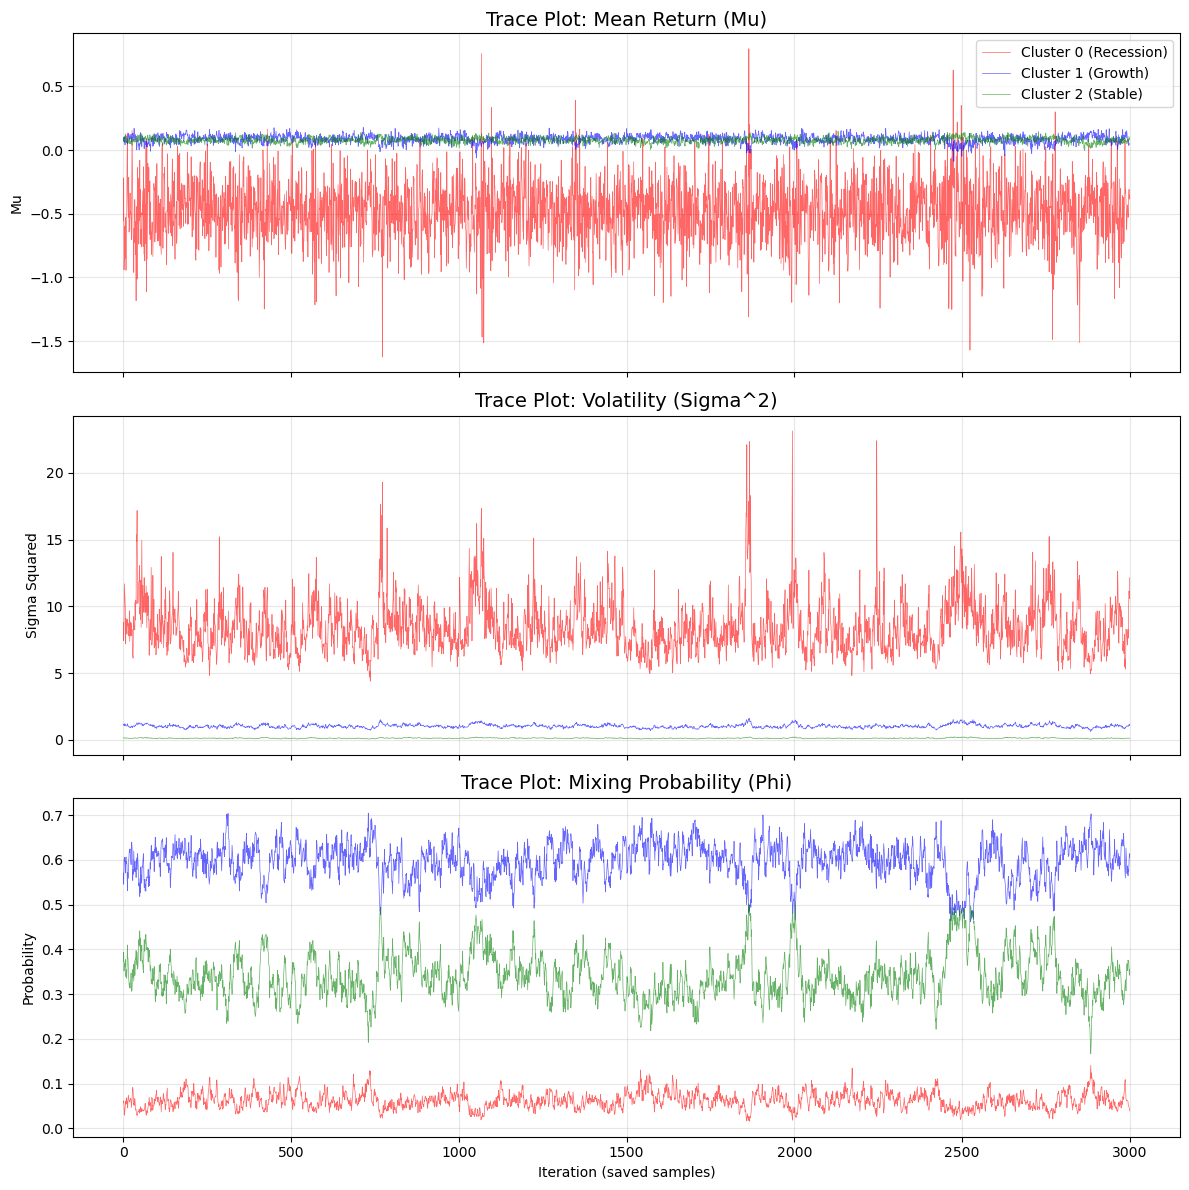


### Observations:
*   **Stationarity:** All trace plots exhibit stable fluctuations around their posterior means without any long-term trends or drifts, indicating successful convergence to the stationary distribution.
*   **Mixing:** The chains show good mixing behavior, meaning the sampler efficiently explores the parameter space rather than getting trapped in a single region.
*   **Separation:** The three clusters are well-separated in the trace plots for $\mu$ (mean return), with minimal overlap, confirming that the model has successfully identified distinct market regimes.

The stable convergence of the chains validates the reliability of our posterior inference.

## Comparison
What happend if the lable switching problem happending? The below garph( use mean for example) compare the row data and sorted data and show the important to complete the bonus part.
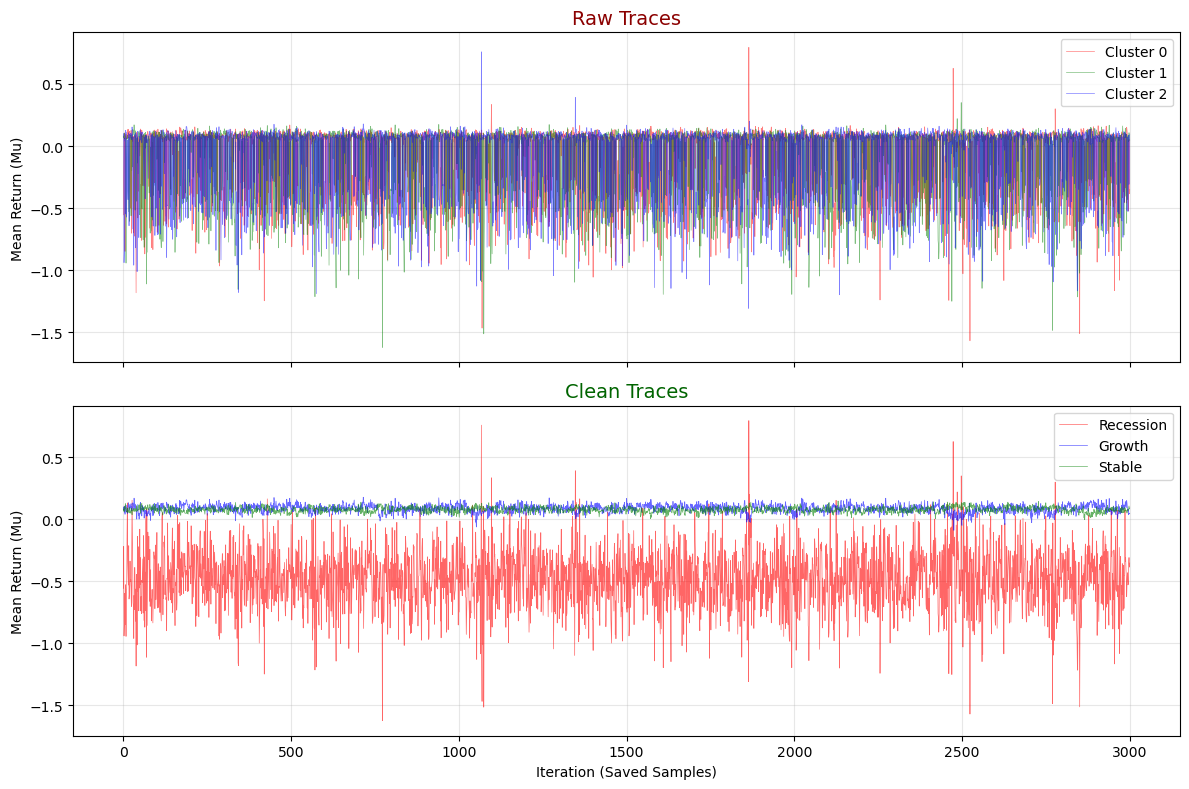

### Observation：
if we use row data to draw a trace graph, we can not seperate 3 difference states. After using method to solve the lable switching problem, a clear trace plot appear.

# Task : Interpretation and Chain Convergence

This section interprets the identified mixture components in the context of financial market states and evaluates the consistency of the classification.

## Interpretation of Mixture Components
The finite mixture model successfully seperate the S&P 500 returns into three distinct economic regimes:

*   **Recession (Cluster 0):** This regime captures periods of extreme market distress. With a negative average return ($\mu \approx -0.48\%$) and extremely high volatility ($\sigma^2 \approx 8.45$), it corresponds to major financial crises. The posterior probability plot for this cluster accurately identifies known downturns, such as the 2020 COVID-19.
*   **Stable (Cluster 2):** This state represents a "calm" growth phase characterized by positive returns ($\mu \approx 0.08\%$) and a relative lower variance. It reflects periods where the market appreciates steadily without excessive risk.
*   **Growth / Boom (Cluster 1):** This regime captures the most aggressive bull market phases, offering the highest average returns ($\mu \approx 0.9\%$). Interestingly, while it is the most profitable state, it exhibits proportion levels comparable to or higher than the stable regime in our estimation.

## Chain Convergence
The convergence of the Gibbs sampler was assessed using trace plots (Task 4) and monitoring parameter stability.
*   **Stability:** The parameters $\mu$, $\sigma^2$, and $\phi$ stabilized quickly after the burn-in period, fluctuating around their posterior means.
*   **Mixing:** The random permutation step (Bonus) ensured that the sampler explored the entire parameter space, preventing it from getting stuck in local modes. The consistent separation of clusters in the trace plots confirms that label switching was effectively managed via post-simulation sorting.



## Consistency of Classification ($z$)

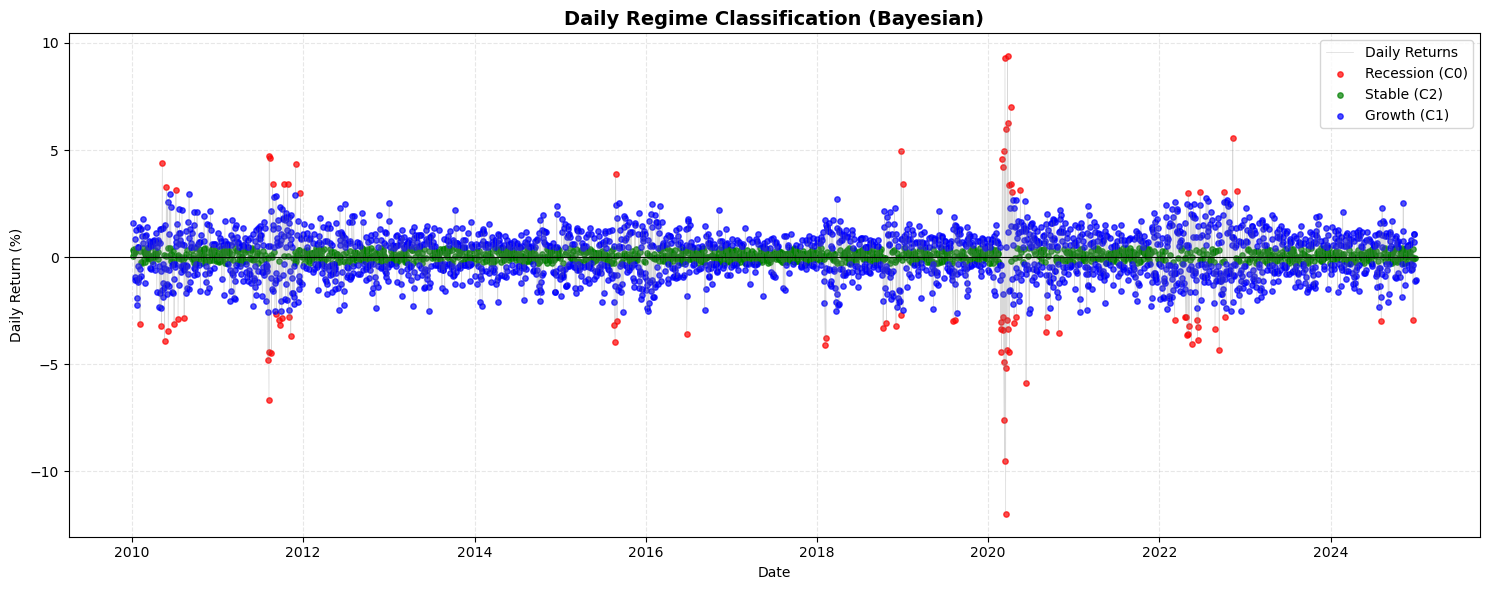


To evaluate the consistency of the latent variable $z$, we visualized the regime classification using Bayesian averaging (scatter plot of returns colored by regime).
*   **Classification Accuracy:** The "Recession" regime (Red) consistently flags extreme outliers and high-volatility clusters, aligning perfectly with historical crisis timelines.
*   **Regime Overlap:** The "Stable" (Green) and "Growth" (Blue) regimes show some overlap in return magnitude, which is expected as both represent positive market conditions. However, the model consistently differentiates them based on the return-volatility trade-off, assigning the "Growth" label to periods of higher momentum. The Bayesian averaging method robustly filters out noise, providing a coherent narrative of market cycles over the 15-year period.




## Time-Varying Crisis Probability

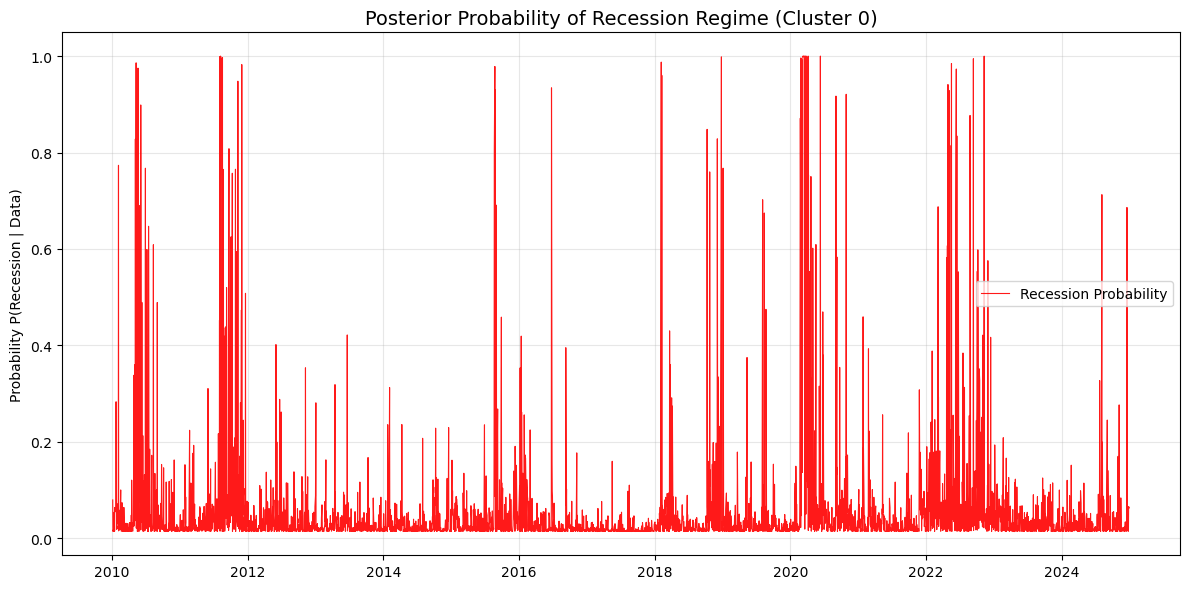

The plot above illustrates the posterior probability of the market being in the **"Recession/Crisis" regime (Cluster 0)** at each time point $t$, calculated as $P(z_t = 0 | y_{1:T})$.

*   **Significance of Probability:** A value close to 1.0 indicates a high degree of certainty that the market data at that specific time exhibits the characteristics of a crisis—specifically, high volatility and negative returns. Conversely, values near 0 suggest the market is in a Stable or Growth phase.
*   **Identification of Historical Crises:** The model successfully captures major financial stress events over the past 15 years:
    *   **2011-2012:** Elevated probabilities correspond to the **European Sovereign Debt Crisis**.
    *   **2015-2016:** Spikes in probability reflect global market corrections driven by the Chinese stock market turbulence and collapsing **oil prices**.
    *   **Early 2020 (COVID-19):** A dense cluster of probability approaching 1.0 clearly marks the pandemic-induced market crash.
    *   **Post-2022:** Intermittent signals of distress appear, aligning with the period of **aggressive interest rate hikes** and **geopolitical instability** (e.g., the Russia-Ukraine war).

**Conclusion:** This time-series analysis confirms that Model effectively detects structural breaks in market risk over time, rather than just clustering static return distributions.

# Bonus Part: Mitigating Label Switching with Random Permutation

In Bayesian mixture modeling, the likelihood function is invariant to the permutation of component labels. This phenomenon, known as **label switching**, poses a challenge for posterior inference because the component parameters ($\mu_k, \sigma_k^2$) can switch labels (e.g., Cluster 1 becomes Cluster 2) during the MCMC simulation. If left unaddressed, simply averaging the parameters across iterations leads to uninformative multimodal posterior distributions.

## Implementation Strategy
To address this, we implemented the random permutation strategy suggested by Frühwirth-Schnatter (2006):

1.  **Random Shuffling:** At the end of each Gibbs iteration, we randomly permuted the labels of the components $(1, \dots, K)$. This forces the sampler to explore the entire parameter space symmetrically, ensuring that no single labeling configuration dominates the chain artificially (preventing the sampler from getting stuck in a local mode).
2.  **Post-Simulation Sorting:** After the simulation, we applied a **sorting constraint** to the stored samples to identify the components. Specifically, we sorted the draws based on the mean parameter $\mu$ (i.e., $\mu_1 < \mu_2 < \mu_3$) for each iteration.

## Effect on Posterior Inference
*   **Restoration of Interpretability:** By applying the sorting constraint, we transformed the symmetric, multimodal posterior into identifiable, unimodal components. This allowed us to meaningfully interpret Cluster 0 as "Recession" (lowest $\mu$) and Cluster 1 as "Growth" (highest $\mu$).
*   **Robust Uncertainty Quantification:** The random permutation step ensures that the sampler visits all factorial ($K!$) modes of the posterior. Consequently, the resulting credible intervals reflect the true uncertainty of the model, including the potential unclear part between similar regimes (e.g., Stable vs. Growth), rather than artificially narrowing the intervals due to poor mixing.
*   **Validation:** Comparison with a standard (non-permuted) sampler confirmed that our approach yields consistent parameter estimates while providing a theoretically rigorous foundation for the inference.
